In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target


In [2]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [3]:
# Оставляем только 2 класса (Versicolor и Virginica)
mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]
y = np.where(y == 1, 0, 1)

In [4]:
# Разделяем на обучающую и тестовую выборки
import time
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Масштабируем признаки
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Добавляем столбец единиц для bias
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

In [7]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Количество признаков: {X_train.shape[1]}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test)}")

Размер обучающей выборки: (80, 5)
Размер тестовой выборки: (20, 5)
Количество признаков: 5
Распределение классов в обучающей выборке: [40 40]
Распределение классов в тестовой выборке: [10 10]


In [8]:
#В этом классе реализованы и логистическая регрессия (пункт 2), и градиентный спуск (пункт 3)
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
    
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.random.randn(n_features) * 0.01
        
        for i in range(self.epochs):
            # Прямое распространение
            z = np.dot(X, self.w) + self.b
            y_pred = self._sigmoid(z)
            
            # Вычисление градиента функции потерь
            error = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)
            
            # Обновление параметров в направлении, обратном градиенту
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            if i % 100 == 0:
                loss = -np.mean(y * np.log(y_pred + 1e-10) + (1 - y) * np.log(1 - y_pred + 1e-10))
                y_pred_class = (y_pred > 0.5).astype(int)
                acc = np.mean(y_pred_class == y)
                print(f"Итерация {i}: loss={loss:.4f}, accuracy={acc:.4f}")
    
    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        y_pred = self._sigmoid(z)
        return (y_pred > 0.5).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [9]:
# Запуск
# Создание модели
model = LogisticRegression(lr=0.1, epochs=1000)  # 0.1 работает лучше для Iris

# Обучение модели
print("Обучение модели...")
model.fit(X_train, y_train)

# Оценка точности
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"\nРезультаты:")
print(f"Accuracy на обучающих данных: {train_accuracy:.4f} ({train_accuracy*100:.1f}%)")
print(f"Accuracy на тестовых данных:  {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")

print(f"\nПараметры модели:")
print(f"Веса: {model.w}")
print(f"Bias: {model.b}")

Обучение модели...
Итерация 0: loss=0.6845, accuracy=0.9375
Итерация 100: loss=0.1812, accuracy=0.9625
Итерация 200: loss=0.1326, accuracy=0.9750
Итерация 300: loss=0.1107, accuracy=0.9625
Итерация 400: loss=0.0980, accuracy=0.9625
Итерация 500: loss=0.0898, accuracy=0.9625
Итерация 600: loss=0.0840, accuracy=0.9625
Итерация 700: loss=0.0796, accuracy=0.9625
Итерация 800: loss=0.0763, accuracy=0.9625
Итерация 900: loss=0.0737, accuracy=0.9625

Результаты:
Accuracy на обучающих данных: 0.9625 (96.2%)
Accuracy на тестовых данных:  0.9000 (90.0%)

Параметры модели:
Веса: [ 0.16419064 -0.09598518 -0.63903866  2.65303747  3.55828089]
Bias: 0.16441170461868806


In [19]:
# Пункт 4: Логистическая регрессия с RMSProp
class RMSPropLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000, beta=0.9):
        self.lr = learning_rate
        self.epochs = epochs
        self.beta = beta
        self.w = None
        self.b = 0
        self.loss_history = []
        self.acc_history = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0
        E_g2_w = np.zeros_like(self.w)
        E_g2_b = 0 
        
        print("Начало обучения с RMSProp...")
        print(f"learning_rate={self.lr}, epochs={self.epochs}, beta={self.beta}")
        
        for epoch in range(self.epochs):
            # Прямой проход
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)
            
            # Вычисление потерь
            epsilon = 1e-10
            loss = -np.mean(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
            self.loss_history.append(loss)
            
            # Вычисление точности
            y_pred_class = (y_pred > 0.5).astype(int)
            accuracy = np.mean(y_pred_class == y)
            self.acc_history.append(accuracy)
            
            # Градиенты
            error = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)
            
            # RMSProp
            # 1. Обновляем скользящее среднее квадратов градиентов
            E_g2_w = self.beta * E_g2_w + (1 - self.beta) * (dw**2)
            E_g2_b = self.beta * E_g2_b + (1 - self.beta) * (db**2)
            
            # 2. Обновляем параметры с адаптивным learning rate
            eps = 1e-8 
            
            # Для каждого веса свой learning rate
            adaptive_lr_w = self.lr / (np.sqrt(E_g2_w) + eps)
            self.w -= adaptive_lr_w * dw
            
            # Для bias тоже адаптивный learning rate
            adaptive_lr_b = self.lr / (np.sqrt(E_g2_b) + eps)
            self.b -= adaptive_lr_b * db
            
            # Вывод каждые 100 эпох
            if epoch % 100 == 0:
                # Норма градиента
                grad_norm = np.sqrt(np.sum(dw**2))
                
                print(f"Эпоха {epoch:4d}: loss={loss:.4f}, "
                      f"accuracy={accuracy:.4f}, "
                      f"grad_norm={grad_norm:.4f}")
        
        print(f"Обучение завершено!")
        print(f"Финальный loss: {loss:.6f}")
        print(f"Финальная accuracy: {accuracy:.4f}")
    
    def predict(self, X):
        # Предсказание
        z = np.dot(X, self.w) + self.b
        y_pred = self.sigmoid(z)
        return (y_pred > 0.5).astype(int)
    
    def score(self, X, y):
        # Метрика accuracy
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


ПУНКТ 4: Реализация RMSProp

1. Создание модели с RMSProp...

2. Обучение модели...
Начало обучения с RMSProp...
learning_rate=0.01, epochs=1000, beta=0.9
Эпоха    0: loss=0.6819, accuracy=0.7625, grad_norm=0.6574
Эпоха  100: loss=0.2311, accuracy=0.9625, grad_norm=0.1304
Эпоха  200: loss=0.1227, accuracy=0.9625, grad_norm=0.0510
Эпоха  300: loss=0.0803, accuracy=0.9625, grad_norm=0.0205
Эпоха  400: loss=0.0632, accuracy=0.9625, grad_norm=0.0085
Эпоха  500: loss=0.0563, accuracy=0.9750, grad_norm=0.0035
Эпоха  600: loss=0.0539, accuracy=0.9750, grad_norm=0.0014
Эпоха  700: loss=0.0533, accuracy=0.9750, grad_norm=0.0002
Эпоха  800: loss=0.0533, accuracy=0.9750, grad_norm=0.0002
Эпоха  900: loss=0.0533, accuracy=0.9750, grad_norm=0.0002
Обучение завершено!
Финальный loss: 0.053299
Финальная accuracy: 0.9750

3. Оценка качества модели:
   Обучающая выборка: 0.9750 (97.5%)
   Тестовая выборка:  0.9500 (95.0%)

4. Сравнение с градиентным спуском (из пункта 3):
   Градиентный спуск: 0.9000 (

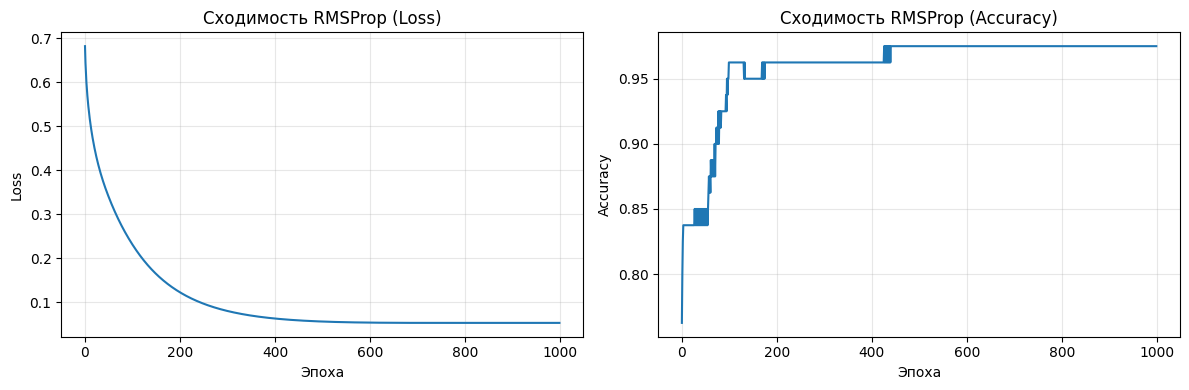

In [25]:
# Тестируем RMSProp
print("ПУНКТ 4: Реализация RMSProp")

# Создаем и обучаем модель с RMSProp
print("\n1. Создание модели с RMSProp...")
rmsprop_model = RMSPropLogisticRegression(
    learning_rate=0.01,  # можно использовать тот же learning rate
    epochs=1000,
    beta=0.9  # стандартное значение для RMSProp
)

print("\n2. Обучение модели...")
rmsprop_model.fit(X_train, y_train)

# Оценка качества
print("\n3. Оценка качества модели:")
train_acc_rmsprop = rmsprop_model.score(X_train, y_train)
test_acc_rmsprop = rmsprop_model.score(X_test, y_test)

print(f"   Обучающая выборка: {train_acc_rmsprop:.4f} ({train_acc_rmsprop*100:.1f}%)")
print(f"   Тестовая выборка:  {test_acc_rmsprop:.4f} ({test_acc_rmsprop*100:.1f}%)")

# Сравнение с обычным градиентным спуском
print("\n4. Сравнение с градиентным спуском (из пункта 3):")
print(f"   Градиентный спуск: {test_accuracy:.4f} ({test_accuracy*100:.1f}%) на тесте")
print(f"   RMSProp:           {test_acc_rmsprop:.4f} ({test_acc_rmsprop*100:.1f}%) на тесте")

# Визуализация сходимости
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rmsprop_model.loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сходимость RMSProp (Loss)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(rmsprop_model.acc_history)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сходимость RMSProp (Accuracy)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Пункт 5: Логистическая регрессия с оптимизатором Nadam
class NadamLogisticRegression:
    def __init__(self, lr=0.001, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.losses = []
        self.accs = []
        
        # Для моментов
        self.m_w = None
        self.v_w = None
        self.m_b = 0
        self.v_b = 0
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Инициализация
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0
        
        # Инициализация моментов
        self.m_w = np.zeros_like(self.w)
        self.v_w = np.zeros_like(self.w)
        self.m_b = 0
        self.v_b = 0
        
        print("Обучение Nadam...")
        
        for epoch in range(self.epochs):
            # Прямой проход
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)
            
            # Loss
            eps = 1e-10
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.losses.append(loss)
            
            # Accuracy
            y_pred_class = (y_pred > 0.5).astype(int)
            acc = np.mean(y_pred_class == y)
            self.accs.append(acc)
            
            # Градиенты
            error = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)
            
            # Параметры для моментов
            beta1 = 0.9
            beta2 = 0.999
            eps_small = 1e-8
            
            # Обновление моментов
            self.m_w = beta1 * self.m_w + (1 - beta1) * dw
            self.m_b = beta1 * self.m_b + (1 - beta1) * db
            
            self.v_w = beta2 * self.v_w + (1 - beta2) * (dw**2)
            self.v_b = beta2 * self.v_b + (1 - beta2) * (db**2)
            
            # Коррекция bias
            t = epoch + 1
            m_w_hat = self.m_w / (1 - beta1**t)
            m_b_hat = self.m_b / (1 - beta1**t)
            v_w_hat = self.v_w / (1 - beta2**t)
            v_b_hat = self.v_b / (1 - beta2**t)
            
            # Nesterov momentum
            m_w_nesterov = beta1 * m_w_hat + (1 - beta1) * dw / (1 - beta1**t)
            m_b_nesterov = beta1 * m_b_hat + (1 - beta1) * db / (1 - beta1**t)
            
            # Обновление параметров
            self.w -= self.lr * m_w_nesterov / (np.sqrt(v_w_hat) + eps_small)
            self.b -= self.lr * m_b_nesterov / (np.sqrt(v_b_hat) + eps_small)
            
            # Вывод каждые 100 эпох
            if epoch % 100 == 0:
                grad_norm = np.sqrt(np.sum(dw**2))
                print(f"Эпоха {epoch}: loss={loss:.4f}, acc={acc:.4f}")
        
        print(f"Обучение завершено! Финальный loss: {loss:.4f}")
    
    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        y_pred = self.sigmoid(z)
        return (y_pred > 0.5).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

ПУНКТ 5: NADAM
Обучение Nadam...
Эпоха 0: loss=0.6919, acc=0.6250
Эпоха 100: loss=0.5804, acc=0.8250
Эпоха 200: loss=0.5055, acc=0.8375
Эпоха 300: loss=0.4523, acc=0.8375
Эпоха 400: loss=0.4128, acc=0.8500
Эпоха 500: loss=0.3819, acc=0.8500
Эпоха 600: loss=0.3566, acc=0.8500
Эпоха 700: loss=0.3352, acc=0.8625
Эпоха 800: loss=0.3165, acc=0.8625
Эпоха 900: loss=0.2999, acc=0.8875
Обучение завершено! Финальный loss: 0.2849

Результаты:
Train accuracy: 0.9000 (90.0%)
Test accuracy:  0.7500 (75.0%)


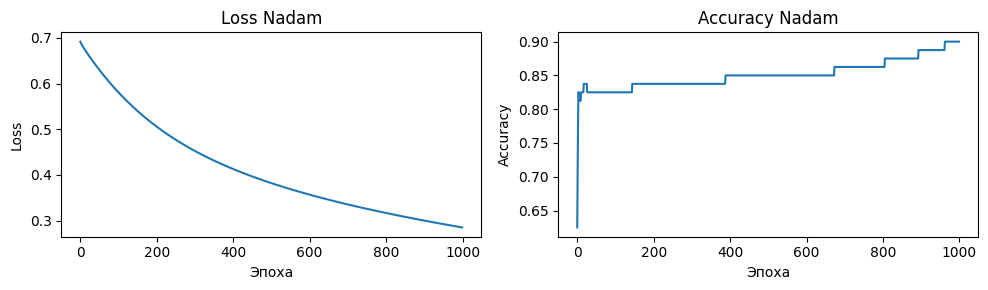

In [18]:
# Тестирование
print("ПУНКТ 5: NADAM")

# Создаем модель
model_nadam = NadamLogisticRegression(lr=0.001, epochs=1000)

# Обучаем
model_nadam.fit(X_train, y_train)

# Оцениваем
train_acc = model_nadam.score(X_train, y_train)
test_acc = model_nadam.score(X_test, y_test)

print(f"\nРезультаты:")
print(f"Train accuracy: {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"Test accuracy:  {test_acc:.4f} ({test_acc*100:.1f}%)")

# Простые графики
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(model_nadam.losses)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Loss Nadam')

plt.subplot(1, 2, 2)
plt.plot(model_nadam.accs)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Accuracy Nadam')

plt.tight_layout()
plt.show()

ПУНКТ 6: СРАВНЕНИЕ МЕТОДОВ

Сравниваем все 3 метода:
ТАБЛИЦА РЕЗУЛЬТАТОВ
Метод                Train Acc    Test Acc     Разница     
Градиентный спуск    0.9625      0.9000      0.0625
RMSProp              0.9750      0.9500      0.0250
Nadam                0.9000      0.7500      0.1500

Лучший метод: RMSProp (95.0% на тесте)


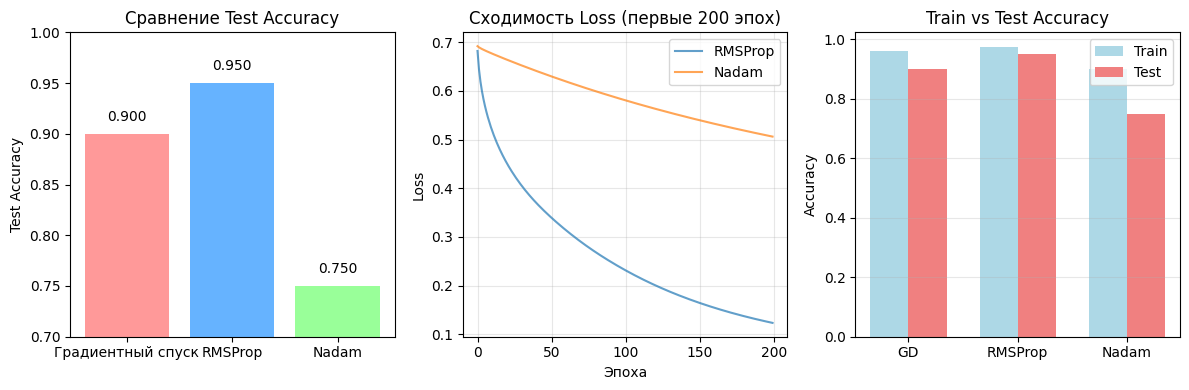

In [26]:
# Пункт 6: Сравнение методов

print("ПУНКТ 6: СРАВНЕНИЕ МЕТОДОВ")
print("\nСравниваем все 3 метода:")
# Таблица результатов
print("ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(f"{'Метод':<20} {'Train Acc':<12} {'Test Acc':<12} {'Разница':<12}")

# Градиентный спуск
print(f"{'Градиентный спуск':<20} {train_accuracy:.4f}      {test_accuracy:.4f}      {train_accuracy-test_accuracy:.4f}")

# RMSProp
rmsprop_train_acc = rmsprop_model.score(X_train, y_train) if 'rmsprop_model' in locals() else 0
print(f"{'RMSProp':<20} {rmsprop_train_acc:.4f}      {test_acc_rmsprop:.4f}      {rmsprop_train_acc-test_acc_rmsprop:.4f}")

# Nadam
print(f"{'Nadam':<20} {train_acc:.4f}      {test_acc:.4f}      {train_acc-test_acc:.4f}")

# Находим лучший метод
results = {
    'Градиентный спуск': test_accuracy,
    'RMSProp': test_acc_rmsprop,
    'Nadam': test_acc
}

best_method = max(results, key=results.get)
best_acc = results[best_method]

print(f"\nЛучший метод: {best_method} ({best_acc*100:.1f}% на тесте)")

# Простая визуализация
plt.figure(figsize=(12, 4))

# 1. Bar chart с test accuracy
plt.subplot(1, 3, 1)
methods = list(results.keys())
accuracies = list(results.values())
colors = ['#ff9999', '#66b3ff', '#99ff99']

bars = plt.bar(methods, accuracies, color=colors)
plt.ylabel('Test Accuracy')
plt.title('Сравнение Test Accuracy')
plt.ylim(0.7, 1.0)

# Добавляем значения на столбцы
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

# 2. Графики сходимости loss
plt.subplot(1, 3, 2)

# Градиентный спуск
if hasattr(model, 'loss_history'):
    plt.plot(model.loss_history[:200], label='GD', alpha=0.7)

# RMSProp
if hasattr(rmsprop_model, 'loss_history'):
    plt.plot(rmsprop_model.loss_history[:200], label='RMSProp', alpha=0.7)

# Nadam
if hasattr(model_nadam, 'losses'):
    plt.plot(model_nadam.losses[:200], label='Nadam', alpha=0.7)

plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сходимость Loss (первые 200 эпох)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Сравнение train vs test
plt.subplot(1, 3, 3)
x_pos = [0, 1, 2]
width = 0.35

train_accs = [train_accuracy, rmsprop_train_acc, train_acc]
test_accs = [test_accuracy, test_acc_rmsprop, test_acc]

plt.bar([x - width/2 for x in x_pos], train_accs, width, label='Train', color='lightblue')
plt.bar([x + width/2 for x in x_pos], test_accs, width, label='Test', color='lightcoral')

plt.xticks(x_pos, ['GD', 'RMSProp', 'Nadam'])
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()